# 🏁 Análise da Corrida

Agora que a corrida foi revelada, é hora de nos aprofundarmos no porquê a McLaren acabou na segunda e quarta posições em vez de primeira e segunda.

## ⚙️ Configuração de ambiente

In [ ]:
import fastf1 as ff1
from fastf1 import plotting
from fastf1.logger import set_log_level
from matplotlib import pyplot as plt

from plots.laps import plot_driver_lap_time_distributions, plot_lap_time_box_plots
from plots.positions import plot_position_changes, plot_starting_grid
from plots.tyres import plot_tyre_strategy

set_log_level("ERROR")
ff1.Cache.enable_cache("cache")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

%matplotlib widget

## 📚 Agregando e limpando dados

In [2]:
race = ff1.get_session(2025, "Qatar", "R")
race.load(telemetry=False)

In [3]:
results = race.results

In [4]:
grid = results[results["GridPosition"] > 0].sort_values(by="GridPosition")
pit_lane_starters = results[results["GridPosition"] == 0]

In [5]:
race_laps = race.laps.copy()
race_laps.loc[:, "LapTime_s"] = race_laps.LapTime.dt.total_seconds()

In [6]:
race_push_laps = race_laps.pick_quicklaps().copy()

In [7]:
stints = race_laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"])
stints = stints.count().reset_index()
stints = stints.rename(columns={"LapNumber": "StintLength"})

In [8]:
drivers = [race.get_driver(driver)["Abbreviation"] for driver in race.drivers]

In [9]:
point_finishers = race.drivers[:10]

In [10]:
point_finishers

['1', '81', '55', '4', '12', '63', '14', '16', '30', '22']

In [11]:
driver_laps = race_push_laps.pick_drivers(point_finishers)
driver_laps = driver_laps.reset_index()

In [12]:
finishing_order = [race.get_driver(i)["Abbreviation"] for i in point_finishers]

## 🔬 Análise

Vamos observar o grid inicial

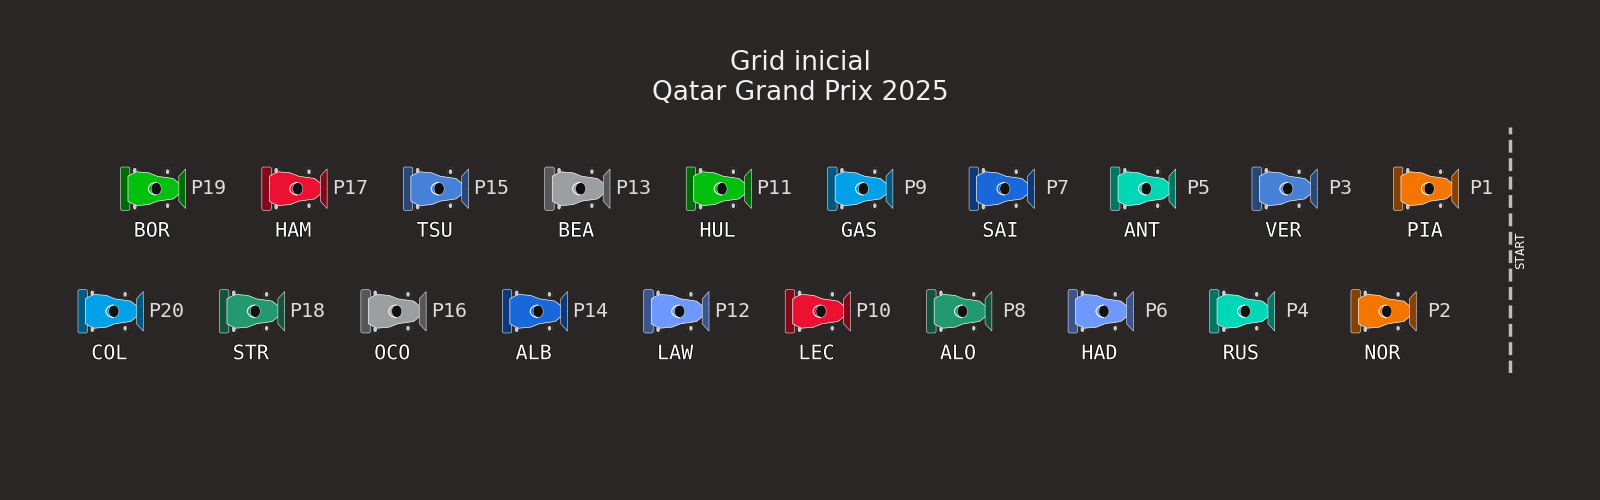

In [13]:
plot_starting_grid(
    race,
    title_str=f"Grid inicial\n{race.event.EventName} {race.event.year}",
)

Perceba que ultrapassagens no início da corrida não são registrados no gráfico a seguir.

É possível perceber que Verstappen perde sua posição para o Norris devido ao seu pit na sétima volta, e à medida que as McLarens entram no pit lane, ele volta ao P1, é ultrapassado mais uma vez por fazer um pit, apenas para voltar ao P1 depois que as McLarens são obrigadas a realizarem um segundo pit stop tardio.

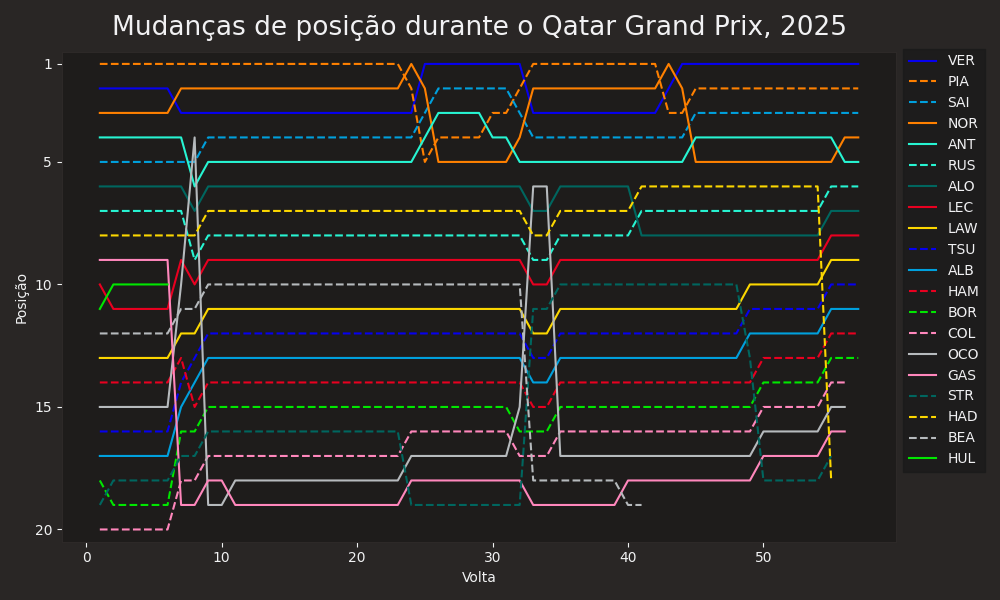

In [14]:
plot_position_changes(
    race,
    title_str=f"Mudanças de posição durante o {race.event.EventName}, {race.event.year}",
    xlabel="Volta",
    ylabel="Posição",
)

No entanto, nesta corrida, temos uma história de superação! Sainz se aproveitou do ótimo ritmo da Williams neste fim de semana. Partindo da P7, ele ultrapassou tanto Hadjar, da Racing Bulls, quanto Russell, da Mercedes, assumindo a P5 logo na primeira volta. Ele também teve um excelente pit stop, o que lhe permitiu reduzir muito o tempo e ultrapassar Antonelli. Conforme as McLarens paravam nos boxes, ele subiu para a P2! Ele acabou sendo ultrapassado por ambas as McLarens depois, caindo para a P4, mas como elas pararam novamente, ele conseguiu segurar a P3.

Este foi um [grande destaque](https://www.formula1.com/en/video/2025-qatar-grand-prix-sainz-crosses-the-line-to-take-an-unbelievable-podium-finish.1850249091945216620 ), pois antes da trajetória de Sainz na Williams em 2025, a última vez que a equipe havia conquistado um pódio em uma corrida completa foi em 2017, garantindo assim um P5 para a Williams Racing no campeonato de construtores.

Esse é um grande exemplo de como alinhar um bom ritmo de corrida, estratégia e oportunismo podem resultar em ótimos resultados na F1.

Ao analisar as voltas rápidas (*push laps*), é possível notar que, durante a corrida, a Williams Racing teve a terceira melhor mediana de tempos de volta, muito próxima à da Ferrari, porém com maior variabilidade. Quanto à McLaren, esta apresentou os melhores tempos de volta entre todas as equipes, com uma margem significativa para a realidade da F1.

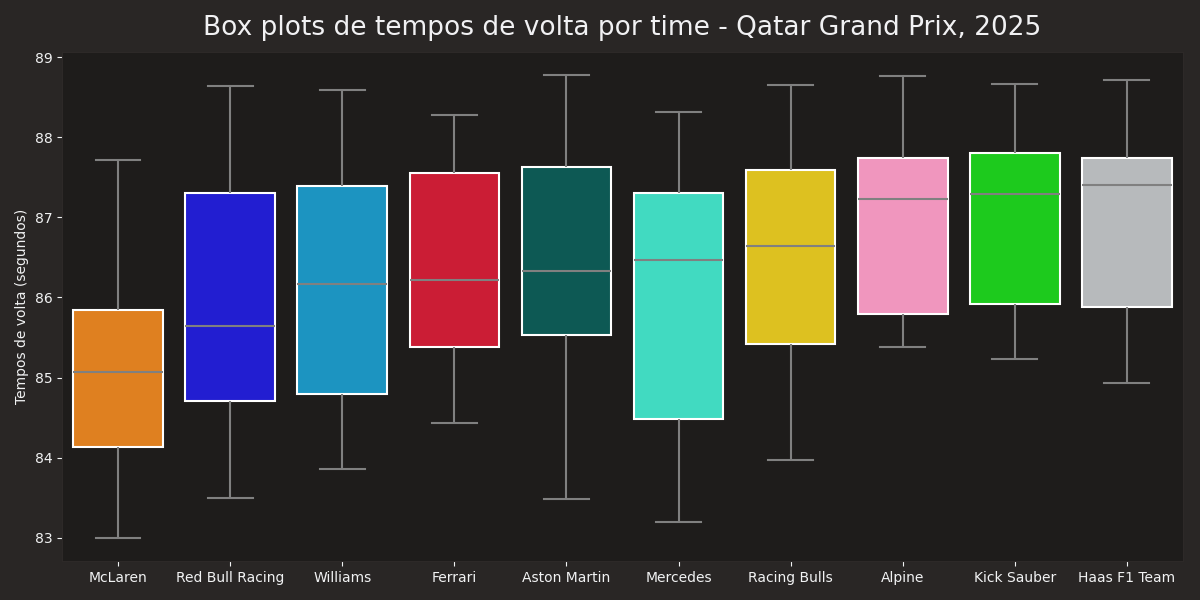

In [15]:
plot_lap_time_box_plots(
    race_push_laps,
    race,
    mode="Team",
    title_str=f"Box plots de tempos de volta por time - {race.event.EventName}, {race.event.year}",
    ylabel="Tempos de volta (segundos)",
)

Ambos pilotos da McLaren foram capazes de vencer o Max em ritmo de corrida em voltas rápidas. E apesar de ter terminado em terceiro lugar, Sainz teve o quinto melhor ritmo.

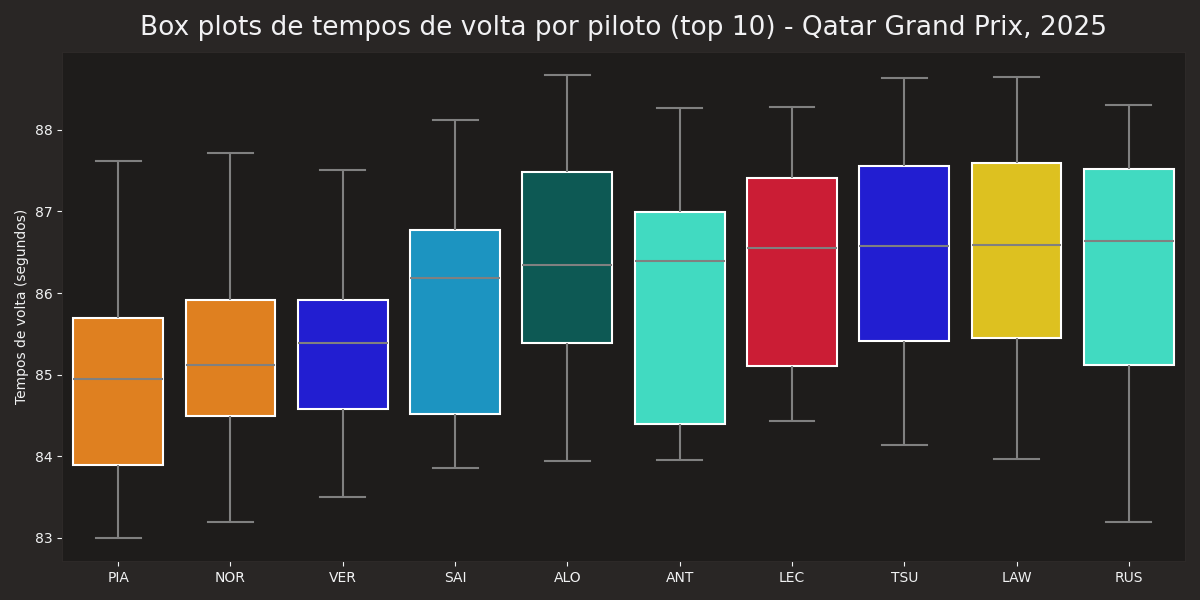

In [23]:
plot_lap_time_box_plots(
    race_push_laps,
    race,
    mode="Driver",
    title_str=f"Box plots de tempos de volta por piloto (top 10) - {race.event.EventName}, {race.event.year}",
    ylabel="Tempos de volta (segundos)",
    point_finishers=point_finishers,
)

Quando se trata de voltas rápidas, é possível visualizar que Sainz estava mais lento em muitas voltas antes de realmente se aproximar a uma performance comparável aos outros 3 pilotos do top 4.

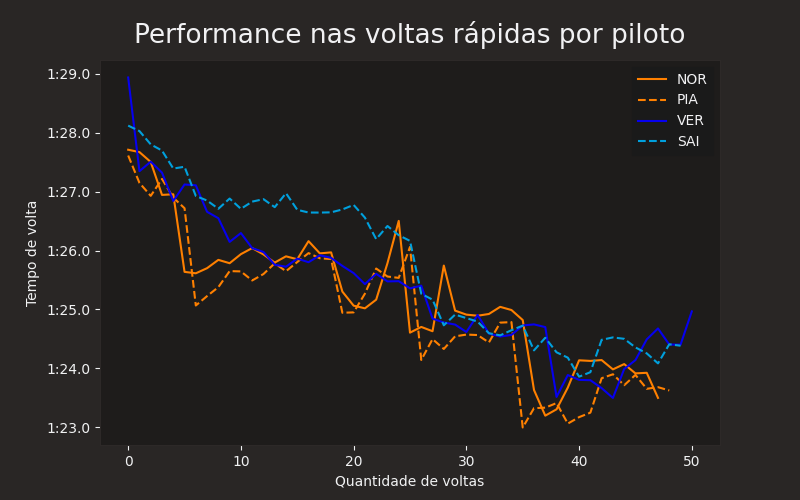

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Quantidade de voltas")
ax.set_ylabel("Tempo de volta")
ax.legend()
ax.set_title("Performance nas voltas rápidas por piloto")
plotting.add_sorted_driver_legend(ax, race)
plt.show()

Finalmente, quando removemos a normalização e incluímos todas as voltas, podemos ver os saltos em tempo de volta que quase custaram o WDC de 2025 para o Lando Norris, da McLaren.

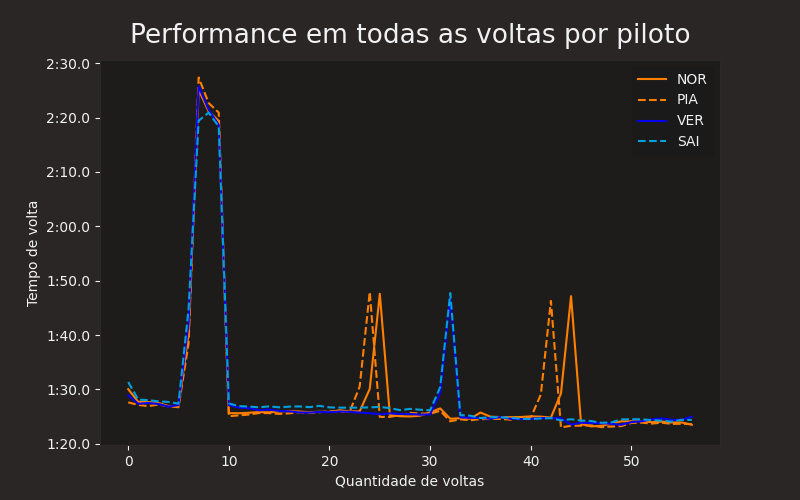

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Quantidade de voltas")
ax.set_ylabel("Tempo de volta")
ax.legend()
ax.set_title("Performance em todas as voltas por piloto")
plotting.add_sorted_driver_legend(ax, race)
plt.show()

Devido os pits tardios, a McLaren teve 3 grandes picos em tempo de volta, em vez de 3. Ademais, os pilotos, atrás do safety car, não conseguirar se aproveitar da vantagem de se manter na pista. Eles tiveram tempos de volta bem similares (ou até piores) do que o Verstappen, que fez um pit. Sainz foi mais rápido do que os outros três mesmo com pit.

Como nenhum outro safety car foi implantado na corrida, a McLaren perdeu sua única oportunidade de um pit stop "gratuito" na corrida. Diferentemente dos anos anteriores, que tiveram no mínimo 3 incidentes, essa teve apenas um.

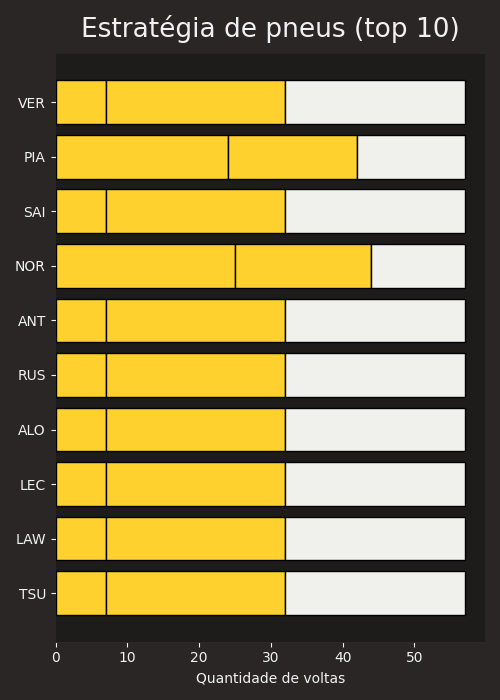

In [22]:
plot_tyre_strategy(
    drivers[:10],
    stints,
    race,
    title_str="Estratégia de pneus (top 10)",
    xlabel="Quantidade de voltas",
)

Isso fez com que Verstappen reduzisse em 13 pontos a vantagem do Norris. Ele foi para a última corrida do ano precisando de 12 pontos para ser capaz de empatar com o Norris.

E por apenas **2** pontos, [ele quase conseguiu](https://www.formula1.com/en/results/2025/drivers). Um homem que estava em um déficit de quase 104 pontos para o líder do WDC nessa temporada.

> Essa corrida quase custou o campeonato mundial do Lando Norris.

Para o Piastri, esse resultado fez com que suas chances de conseguir o campeonato na última corrida se tornassem muito, muito ínfimas. Ele terminou a temporada em P3, por uma diferença de 11 pontos.

Desses, 7 vieram apenas dessa corrida.